# Tidal analysis and prediction — Schureman vs Foreman

This notebook demonstrates harmonic tidal analysis and prediction using two methods:

- **Schureman (1941)**: nodal correction factors derived analytically from astronomical constants.
- **Foreman (2004)**: nodal correction factors derived from tabulated satellite data; can give slightly different results for some constituents.

We use historical tide gauge data from Vlissingen (VLISSGN) to fit tidal constituents with both methods, compute the practical surge, and compare the results.

**References:**
- Schureman, P. (1941). *Manual of Harmonic Analysis and Prediction of Tides*. U.S. Coast and Geodetic Survey.
- M.G.G. Foreman (2004). *Manual for Tidal Heights Analysis and Prediction*, Institute of Ocean Sciences, Patricia Bay, Sidney B.C., Canada.

In [1]:
# Import necessary packages
using Pkg
Pkg.activate(".")
Pkg.precompile()
using hatyan_core
using Plots
using Dates

  Activating project at `~/deepblack/src/AIHydroPoints.jl.git`


In [2]:
# Load observed water levels from a DONAR file
obs = read_donar_timeseries("test_data/VLISSGN_obs19.txt")
@show obs
# Select a subset of the data for analysis
start_time = DateTime("1990-01-01T00:00:00")
end_time   = DateTime("1990-12-31T23:59:59")
obs1990 = select_timespan(obs, start_time, end_time)
@show obs1990
# Select a subset for the February 1990 storm event
start_time_feb1990 = DateTime("1990-02-22T00:00:00")
end_time_feb1990   = DateTime("1990-03-02T23:59:59")
obs_feb1990 = select_timespan(obs, start_time_feb1990, end_time_feb1990)
@show obs_feb1990

obs = TimeSeries:
   Quantity: WATHTE (NAP)
   Source: VLISSGN
   Number of locations: 1
   Number of time points: 166560
   Data shape: (1, 166560)
   Times: 1976-01-01T00:00:00 to 1994-12-31T23:00:00
   Locations: Vlissingen

obs1990 = TimeSeries:
   Quantity: WATHTE (NAP)
   Source: VLISSGN
   Number of locations: 1
   Number of time points: 8760
   Data shape: (1, 8760)
   Times: 1990-01-01T00:00:00 to 1990-12-31T23:00:00
   Locations: Vlissingen

obs_feb1990 = TimeSeries:
   Quantity: WATHTE (NAP)
   Source: VLISSGN
   Number of locations: 1
   Number of time points: 216
   Data shape: (1, 216)
   Times: 1990-02-22T00:00:00 to 1990-03-02T23:00:00
   Locations: Vlissingen



TimeSeries: WATHTE (NAP) from VLISSGN, with 1 locations, from 1990-02-22T00:00:00 until 1990-03-02T23:00:00.


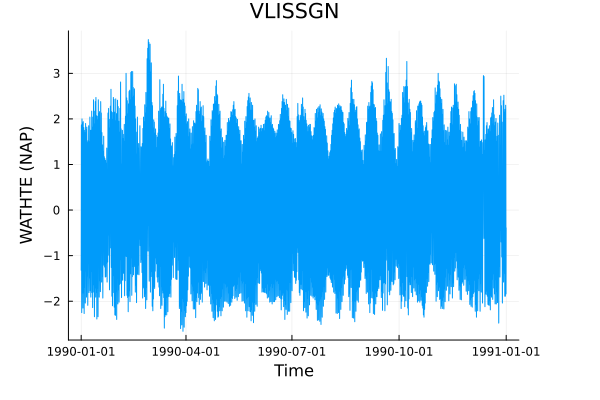

In [3]:
# Plot the observed water levels for 1990
plot(obs1990, label=false)

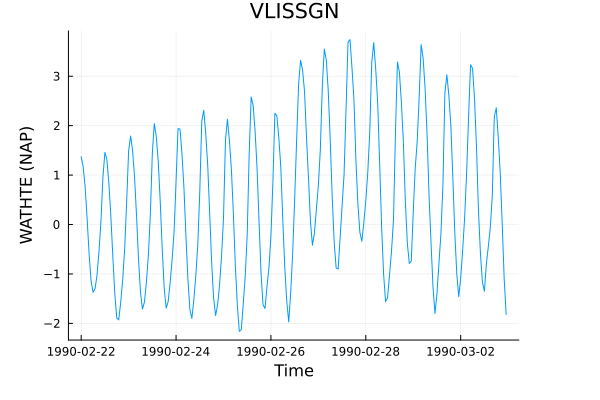

In [4]:
# Plot observed water levels during the February 1990 storm event
plot(obs_feb1990, label=false)

## Harmonic analysis

In [5]:
# Choose a constituent set appropriate for the record length
# "year" = 95 constituents (A0 + 94), requires ~1 year of data
const_list = constituent_list("year")

# Fit constituents by least-squares harmonic analysis — both methods
tc_s = analysis(obs, const_list, "schureman")
tc_f = analysis(obs, const_list, "foreman")
@show tc_s
@show tc_f

tc_s = TidalConstituents:
   Quantity:         WATHTE (NAP)
   Source:           VLISSGN | analysis(schureman)
   Locations:        Vlissingen
   N locations:      1
   N constituents:   95
   Constituents:     A0, SA, SM, Q1, O1, M1C, P1, S1, K1, 3MKS2, 3MS2, OQ2, MNS2, 2ML2S2, NLK2, MU2, N2, NU2, MSK2, MPS2, M2, MSP2, MKS2, LABDA2, 2MN2, T2, S2, K2, MSN2, 2SM2, SKM2, NO3, 2MK3, 2MP3, SO3, MK3, SK3, 4MS4, 2MNS4, 3MS4, MN4, 2MLS4, 2MSK4, M4, 3MN4, MS4, MK4, 2MSN4, S4, MNO5, 3MK5, 2MP5, 3MO5, MSK5, 3KM5, 3MNS6, 2NM6, 4MS6, 2MN6, 2MNU6, 3MSK6, M6, MSN6, MKNU6, 2MS6, 2MK6, 3MSN6, 2SM6, MSK6, 2MNO7, M7, 2MSO7, 2(MN)8, 3MN8, M8, 2MSN8, 2MNK8, 3MS8, 3MK8, 2(MS)8, 2MSK8, 3MNK9, 4MK9, 3MSK9, 4MN10, M10, 3MSN10, 4MS10, 2(MS)N10, 3M2S10, 4MSK11, M12, 4MSN12, 5MS12, 4M2S12
   Data shape:       (1, 95) [locations × constituents]

tc_f = TidalConstituents:
   Quantity:         WATHTE (NAP)
   Source:           VLISSGN | analysis(foreman)
   Locations:        Vlissingen
   N locations:      1
   N c

TidalConstituents: WATHTE (NAP) from VLISSGN | analysis(foreman), 1 locations, 95 constituents.


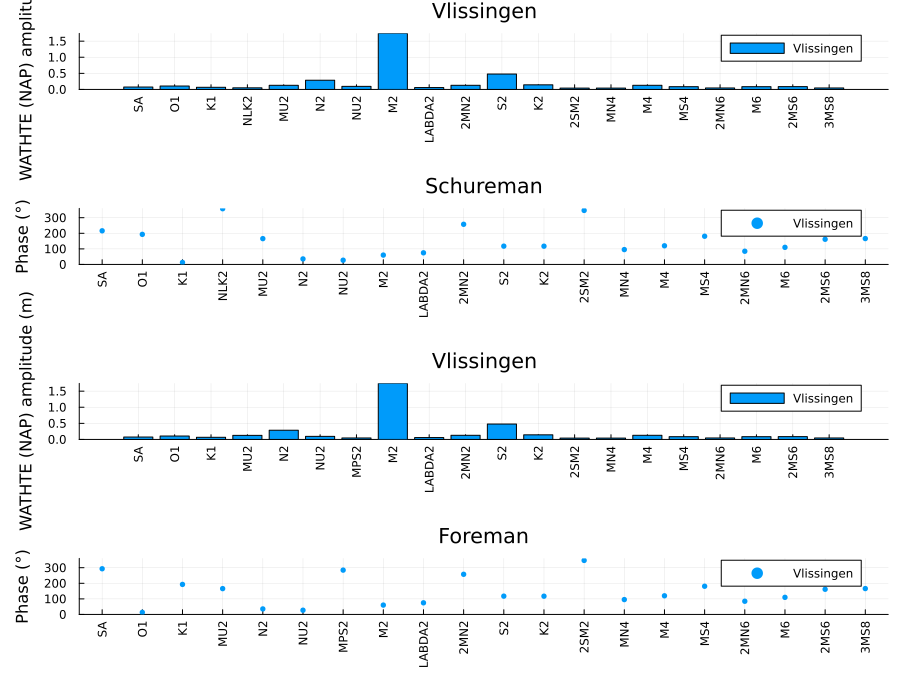

In [6]:
# Plot the tidal constituents for each method (top 20 by amplitude, sorted by frequency)
p_s = plot(tc_s, title="Schureman")
p_f = plot(tc_f, title="Foreman")
plot(p_s, p_f, layout=(2, 1), size=(900, 700))

## Compare M2 results

In [7]:
# Compare M2 amplitude and phase between the two methods
for (label, tc) in [("Schureman", tc_s), ("Foreman", tc_f)]
    A     = get_amplitudes(tc)
    phi   = get_phases(tc)
    names = get_constituent_names(tc)
    i_M2  = findfirst(==("M2"), names)
    println("[$label]")
    println("  M2 amplitude : ", A[1, i_M2], " m")
    println("  M2 phase     : ", phi[1, i_M2], " °")
    println("  Source       : ", get_source(tc))
    println()
end

[Schureman]
  M2 amplitude : 1.7408864 m
  M2 phase     : 60.08594 °
  Source       : VLISSGN | analysis(schureman)

[Foreman]
  M2 amplitude : 1.7408335 m
  M2 phase     : 60.076645 °
  Source       : VLISSGN | analysis(foreman)



## Tidal prediction

In [8]:
# Predict water levels for 1990 with each method
# prediction() reads the method from tc.source automatically
pred1990_s = prediction(tc_s, get_times(obs1990))
pred1990_f = prediction(tc_f, get_times(obs1990))

TimeSeries: WATHTE (NAP) from VLISSGN | analysis(foreman) | prediction, with 1 locations, from 1990-01-01T00:00:00 until 1990-12-31T23:00:00.


## Prediction statistics

In [9]:
# Validation statistics: each tidal prediction vs observations (1990)
stats_s = compute_statistics(obs1990, pred1990_s)
stats_f = compute_statistics(obs1990, pred1990_f)
println("Schureman vs observations:")
println(stats_s)
println("\nForeman vs observations:")
println(stats_f)

Schureman vs observations:
1×9 DataFrame
 Row │ location_id  location_name  n_values  signal_rmse  bias        rmse      mae       max_error  min_error 
     │ Int64        String         Int64     Float64      Float64     Float64   Float64   Float64    Float64   
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │           1  Vlissingen         8760      1.34193  -0.0306597  0.296668  0.199271    1.27785   -2.09083

Foreman vs observations:
1×9 DataFrame
 Row │ location_id  location_name  n_values  signal_rmse  bias       rmse      mae       max_error  min_error 
     │ Int64        String         Int64     Float64      Float64    Float64   Float64   Float64    Float64   
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │           1  Vlissingen         8760      1.34193  -0.030645  0.299068  0.201491    1.29431   -2.12668


In [10]:
# Statistics of the difference between the two predictions (Foreman − Schureman)
stats_diff = compute_statistics(pred1990_s, pred1990_f)
println("Foreman vs Schureman prediction difference:")
println(stats_diff)

Foreman vs Schureman prediction difference:
1×9 DataFrame
 Row │ location_id  location_name  n_values  signal_rmse  bias       rmse       mae        max_error  min_error  
     │ Int64        String         Int64     Float64      Float64    Float64    Float64    Float64    Float64    
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │           1  Vlissingen         8760      1.29667  1.4696e-5  0.0305268  0.0254285  0.0852602  -0.0871768


## Surge computation

In [11]:
# Compute the practical surge: observed minus predicted tidal signal
surge1990_s = TimeSeries(
    get_values(obs1990) .- get_values(pred1990_s),
    get_times(obs1990), get_names(obs1990),
    get_longitudes(obs1990), get_latitudes(obs1990),
    "surge", get_source(obs1990))

surge1990_f = TimeSeries(
    get_values(obs1990) .- get_values(pred1990_f),
    get_times(obs1990), get_names(obs1990),
    get_longitudes(obs1990), get_latitudes(obs1990),
    "surge", get_source(obs1990))

TimeSeries: surge from VLISSGN, with 1 locations, from 1990-01-01T00:00:00 until 1990-12-31T23:00:00.


## Full-year overview (1990)

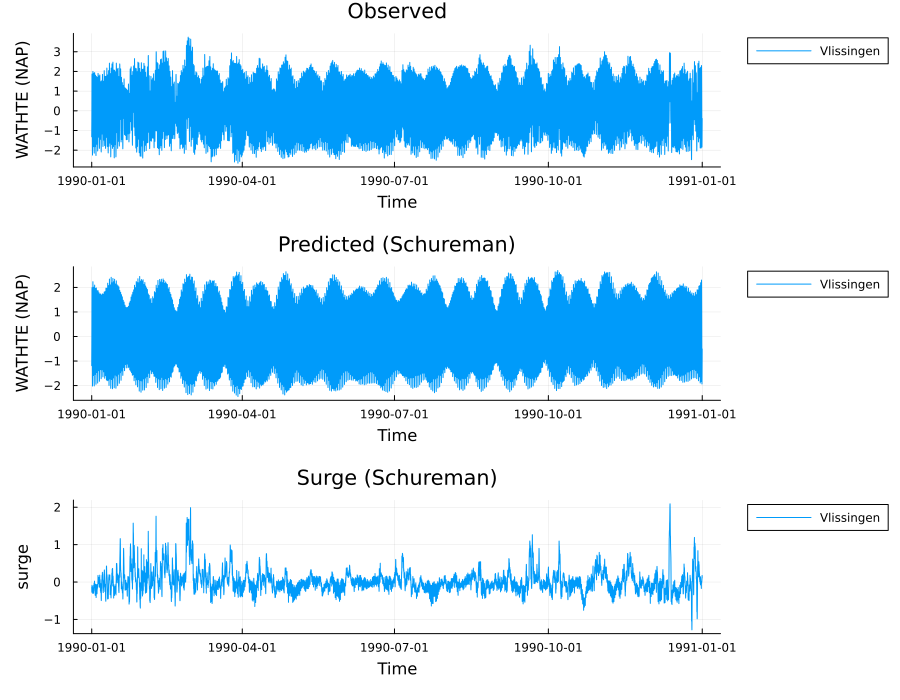

In [12]:
# Schureman: observed, predicted, and surge for 1990
p1 = plot(obs1990,      title="Observed")
p2 = plot(pred1990_s,   title="Predicted (Schureman)")
p3 = plot(surge1990_s,  title="Surge (Schureman)")
plot(p1, p2, p3, layout=(3, 1), size=(900, 700))

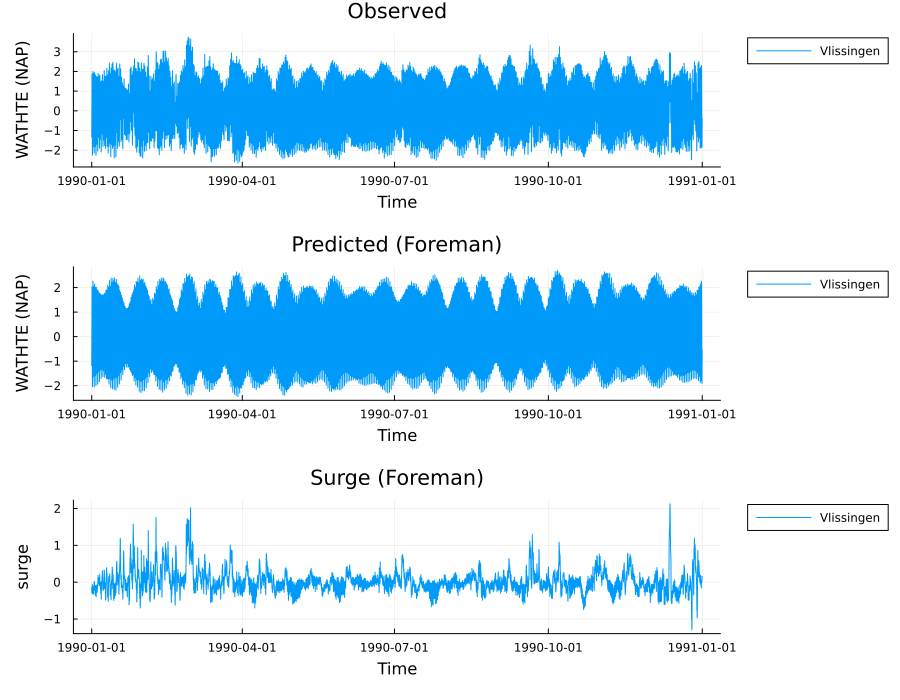

In [13]:
# Foreman: observed, predicted, and surge for 1990
p1 = plot(obs1990,      title="Observed")
p2 = plot(pred1990_f,   title="Predicted (Foreman)")
p3 = plot(surge1990_f,  title="Surge (Foreman)")
plot(p1, p2, p3, layout=(3, 1), size=(900, 700))

## Storm event — February 1990

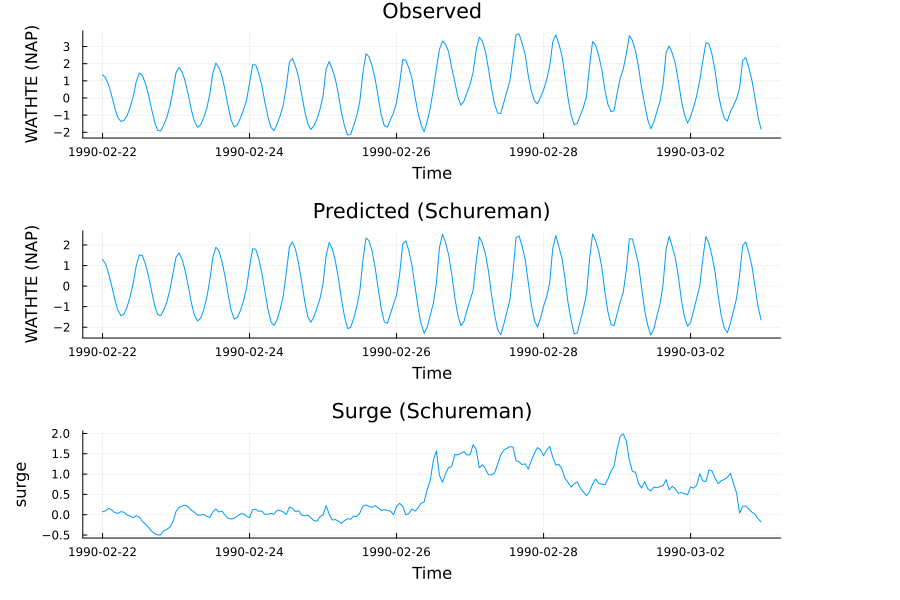

In [14]:
# Schureman — storm event
pred_feb1990_s  = select_timespan(pred1990_s,  start_time_feb1990, end_time_feb1990)
surge_feb1990_s = select_timespan(surge1990_s, start_time_feb1990, end_time_feb1990)

p1 = plot(obs_feb1990,     title="Observed",             label=false)
p2 = plot(pred_feb1990_s,  title="Predicted (Schureman)", label=false)
p3 = plot(surge_feb1990_s, title="Surge (Schureman)",     label=false)
plot(p1, p2, p3, layout=(3, 1), size=(900, 600))

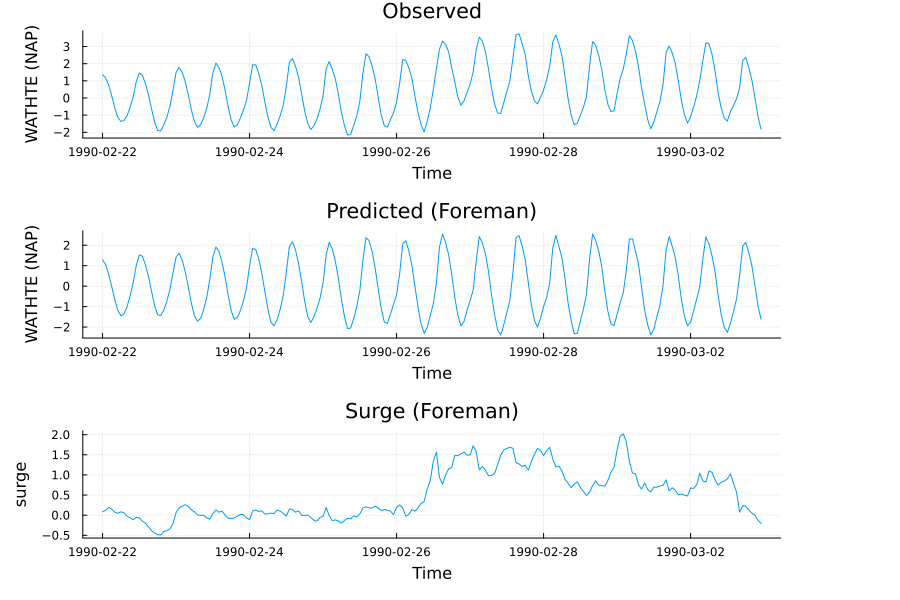

In [15]:
# Foreman — storm event
pred_feb1990_f  = select_timespan(pred1990_f,  start_time_feb1990, end_time_feb1990)
surge_feb1990_f = select_timespan(surge1990_f, start_time_feb1990, end_time_feb1990)

p1 = plot(obs_feb1990,     title="Observed",           label=false)
p2 = plot(pred_feb1990_f,  title="Predicted (Foreman)", label=false)
p3 = plot(surge_feb1990_f, title="Surge (Foreman)",     label=false)
plot(p1, p2, p3, layout=(3, 1), size=(900, 600))

## Surge spectrum

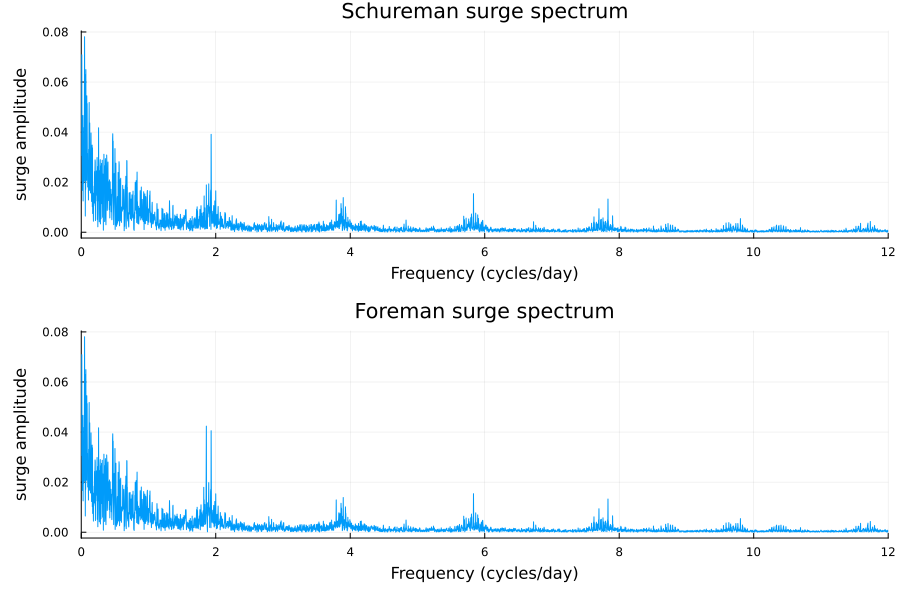

In [16]:
# Amplitude spectrum of the 1990 surge for both methods (cycles per day, up to 12 cpd)
p_s = plot(fft_series(surge1990_s), freq_max=12, label=false, title="Schureman surge spectrum")
p_f = plot(fft_series(surge1990_f), freq_max=12, label=false, title="Foreman surge spectrum")
plot(p_s, p_f, layout=(2, 1), size=(900, 600))